In [2]:
import numpy as np
import polars as pl
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from pycaret.regression import *  # noqa: F403
from sklearn.model_selection import PredefinedSplit
import matplotlib.pyplot as plt
from path_config import PathConfig
from sklearn.neighbors import kneighbors_graph
paths = PathConfig()

In [3]:
def haversine_np(lat1, lon1, lat2, lon2):
    R = 6371000  # Dünya yarıçapı (metre)
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

def create_folds(data, test_cluster, train_clusters, cluster_col="cluster"):
    used_clusters = set(train_clusters + [test_cluster])
    data = data[data[cluster_col].isin(used_clusters)].reset_index(drop=True)
    fold_indices = np.full(len(data), -1) 
    fold_indices[data[cluster_col] == test_cluster] = 0
    return data, PredefinedSplit(fold_indices)


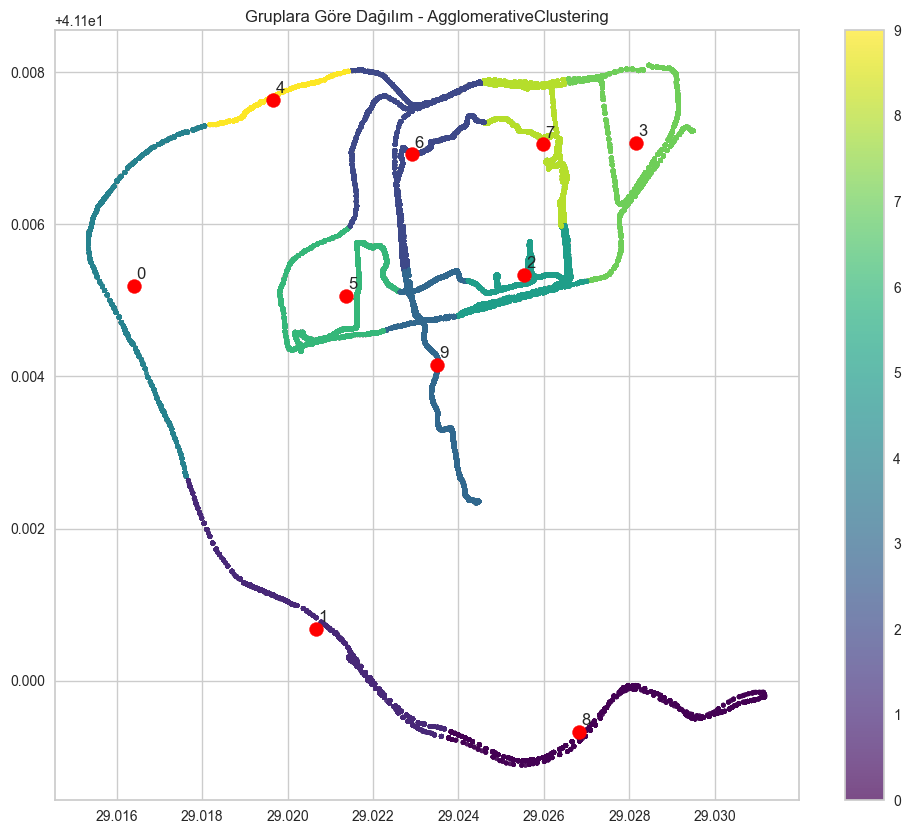

In [ ]:
data = pl.read_parquet(paths._processed_saha_olcum_dir / "merged_aggregated_data_dl.parquet")
unique_coords = data.unique(subset=["Longitude", "Latitude"]).select(["Longitude", "Latitude"])

x, y = unique_coords["Longitude"], unique_coords["Latitude"]
n = 10
X = np.concatenate((np.array(x).reshape(1,-1), np.array(y).reshape(1,-1)))
X = X.T

knn_graph = kneighbors_graph(X, 35, include_self=False, n_jobs=-1)
aggc = AgglomerativeClustering(n_clusters=n, linkage= "ward", connectivity = knn_graph).fit(X)

unique_coords = unique_coords.with_columns(
    pl.Series("cluster", aggc.labels_)
)

data = data.join(
    unique_coords.select(["Longitude", "Latitude", "cluster"]),
    on=["Longitude", "Latitude"],
    how="left"
)

cluster_centers_aggc = data.group_by("cluster").agg([
    pl.col("Longitude").mean(),
    pl.col("Latitude").mean()
])

cluster_centers_aggc_x = np.array(cluster_centers_aggc["Longitude"])
cluster_centers_aggc_y = np.array(cluster_centers_aggc["Latitude"])

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(1, 1, 1)

x, y = data["Longitude"], data["Latitude"]

sc = ax.scatter(
    x,
    y,
    c=data["cluster"],
    cmap="viridis",
    s=10,
    alpha=0.7
)

ax.scatter(
    cluster_centers_aggc_x,
    cluster_centers_aggc_y,
    s=100,
    c="red",
    
)

for i, (x_, y_) in enumerate(zip(cluster_centers_aggc_x, cluster_centers_aggc_y)):
    ax.annotate(str(i), (x_,y_), textcoords="offset points", xytext=(5, 5), ha='center')
    
ax.set_title("Gruplara Göre Dağılım - AgglomerativeClustering")

cbar = plt.colorbar(sc)

plt.show()
# clusterlar her seferinde farklı oluşuyor, bu sebeple clusterlı veriyi kaydediyorum. 
# data.write_parquet(paths._processed_saha_olcum_dir / "merged_aggregated_clustered_data_dl.parquet")

aggc_train_test = {
    1:[2,3,4,5,6,7,9],
    2:[0,1,4,5,6,8],
    3:[1,4,5,6,8,9,0],
    4:[1,2,3,5,7,8,9],
    5:[1,2,3,4,7,8,0],
    6:[1,2,3,8,0],
    7:[1,4,5,8,9,0],
    8:[2,3,4,5,6,7,9,0],
    9:[1,3,4,7,8,0],
    0:[2,3,5,6,7,8,9]
}

In [4]:
aggc_train_test = {
    1:[2,3,4,5,6,7,9],
    2:[0,1,4,5,6,8],
    3:[1,4,5,6,8,9,0],
    4:[1,2,3,5,7,8,9],
    5:[1,2,3,4,7,8,0],
    6:[1,2,3,8,0],
    7:[1,4,5,8,9,0],
    8:[2,3,4,5,6,7,9,0],
    9:[1,3,4,7,8,0],
    0:[2,3,5,6,7,8,9]
}

In [5]:
df = pd.read_parquet(paths._processed_saha_olcum_dir / "merged_aggregated_clustered_data_dl.parquet")
df

,Time,Longitude,Latitude,NR_UE_RSRP_0,NR_UE_RSRQ_0,NR_UE_SINR_0,NR_UE_Nbr_RSRP_0,NR_UE_Nbr_RSRP_1,NR_UE_Nbr_RSRP_2,NR_UE_Nbr_RSRP_3,...,MIMO,TOP_1_NBR_PCI_LONGITUDE_AVG,TOP_1_NBR_PCI_LATITUDE_AVG,TOP_2_NBR_PCI_LONGITUDE_AVG,TOP_2_NBR_PCI_LATITUDE_AVG,TOP_3_NBR_PCI_LONGITUDE_AVG,TOP_3_NBR_PCI_LATITUDE_AVG,TOP_4_NBR_PCI_LONGITUDE_AVG,TOP_4_NBR_PCI_LATITUDE_AVG,cluster
0,2025-03-14 12:14:33.444,29.02949,41.10723,NaN,None,None,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
1,2025-03-14 12:14:33.444,29.02949,41.10723,NaN,None,None,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
2,2025-03-14 12:14:33.444,29.02949,41.10723,NaN,None,None,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
3,2025-03-14 12:14:33.444,29.02949,41.10723,NaN,None,None,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
4,2025-03-14 12:14:34.000,29.02949,41.10723,NaN,None,None,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215894,2025-03-14 14:52:51.655,29.02441,41.10234,NaN,None,None,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
215895,2025-03-14 14:52:51.655,29.02441,41.10234,NaN,None,None,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
215896,2025-03-14 14:52:51.655,29.02441,41.10234,NaN,None,None,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
215897,2025-03-14 14:52:51.655,29.02441,41.10234,NaN,None,None,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3


In [6]:
object_cols = df.select_dtypes(include=['object']).columns.tolist()

df_fixed = df.copy()

for col in object_cols:
    # Unique değerleri al (null'ları çıkar)
    unique_vals = df[col].dropna().unique()
    
    # Tümü sayıya çevrilebilir mi kontrol et
    all_numeric = True
    for val in unique_vals:
        try:
            float(val)
        except (ValueError, TypeError):
            all_numeric = False
            break
    
    if all_numeric:
        # Tümü sayısal string ise numeric yap
        df_fixed[col] = pd.to_numeric(df_fixed[col], errors='coerce')

print(f"Numeric: {len(df_fixed.select_dtypes(include=['number']).columns)}")
print(f"Object: {len(df_fixed.select_dtypes(include=['object']).columns)}")

Numeric: 51
Object: 9


In [7]:
df_fixed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215899 entries, 0 to 215898
Data columns (total 61 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   Time                         215899 non-null  datetime64[ms]
 1   Longitude                    215899 non-null  float64       
 2   Latitude                     215899 non-null  float64       
 3   NR_UE_RSRP_0                 5831 non-null    float64       
 4   NR_UE_RSRQ_0                 5831 non-null    float64       
 5   NR_UE_SINR_0                 5821 non-null    float64       
 6   NR_UE_Nbr_RSRP_0             4229 non-null    float64       
 7   NR_UE_Nbr_RSRP_1             1652 non-null    float64       
 8   NR_UE_Nbr_RSRP_2             278 non-null     float64       
 9   NR_UE_Nbr_RSRP_3             33 non-null      float64       
 10  NR_UE_Nbr_RSRP_4             2 non-null       float64       
 11  NR_UE_Nbr_RSRQ_0          

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4070 Ti SUPER, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

,Description,Value
0,Session id,42
1,Target,Longitude
2,Target type,Regression
3,Original data shape,"(172383, 60)"
4,Transformed data shape,"(172383, 6)"
5,Transformed train set shape,"(164388, 6)"
6,Transformed test set shape,"(7995, 6)"
7,Ignore features,10
8,Ordinal features,3
9,Numeric features,44


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4070 Ti SUPER, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000
1,0.0016,0.0000,0.0018,-0.0147,0.0001,0.0001
2,0.0009,0.0000,0.0013,-0.2203,0.0000,0.0000
Mean,0.0008,0.0000,0.0010,-0.0783,0.0000,0.0000
Std,0.0007,0.0000,0.0008,0.1006,0.0000,0.0000


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

...

,Description,Value
0,Session id,42
1,Target,Latitude
2,Target type,Regression
3,Original data shape,"(172383, 60)"
4,Transformed data shape,"(172383, 6)"
5,Transformed train set shape,"(164388, 6)"
6,Transformed test set shape,"(7995, 6)"
7,Ignore features,10
8,Ordinal features,3
9,Numeric features,44


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4070 Ti SUPER, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000
1,0.0003,0.0000,0.0005,-1.0632,0.0000,0.0000
2,0.0013,0.0000,0.0016,-0.0493,0.0000,0.0000
Mean,0.0006,0.0000,0.0007,-0.3709,0.0000,0.0000
Std,0.0006,0.0000,0.0007,0.4900,0.0000,0.0000


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,0.0054,0.0000,0.0054,-41.3258,0.0001,0.0001


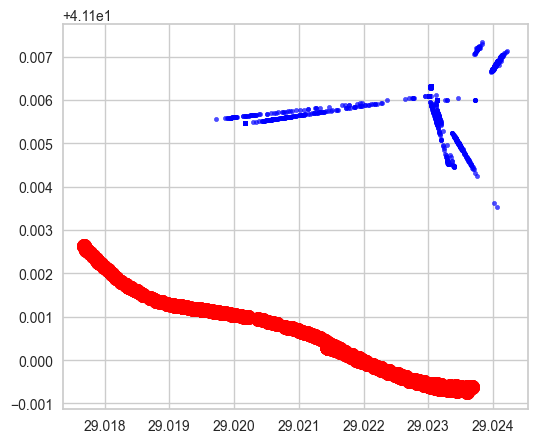

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4070 Ti SUPER, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

,Description,Value
0,Session id,42
1,Target,Longitude
2,Target type,Regression
3,Original data shape,"(164759, 60)"
4,Transformed data shape,"(164759, 6)"
5,Transformed train set shape,"(127255, 6)"
6,Transformed test set shape,"(37504, 6)"
7,Ignore features,10
8,Ordinal features,3
9,Numeric features,44


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4070 Ti SUPER, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000
1,0.0021,0.0000,0.0027,-1.2298,0.0001,0.0001
2,0.0029,0.0000,0.0030,-47.4413,0.0001,0.0001
Mean,0.0017,0.0000,0.0019,-16.2237,0.0001,0.0001
Std,0.0012,0.0000,0.0013,22.0799,0.0000,0.0000


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

...

,Description,Value
0,Session id,42
1,Target,Latitude
2,Target type,Regression
3,Original data shape,"(164759, 60)"
4,Transformed data shape,"(164759, 6)"
5,Transformed train set shape,"(127255, 6)"
6,Transformed test set shape,"(37504, 6)"
7,Ignore features,10
8,Ordinal features,3
9,Numeric features,44


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4070 Ti SUPER, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000
1,0.0012,0.0000,0.0013,-12.4564,0.0000,0.0000
2,0.0015,0.0000,0.0016,-4.4353,0.0000,0.0000
Mean,0.0009,0.0000,0.0010,-5.6305,0.0000,0.0000
Std,0.0006,0.0000,0.0007,5.1551,0.0000,0.0000


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,0.0017,0.0000,0.0020,-8.5902,0.0000,0.0000


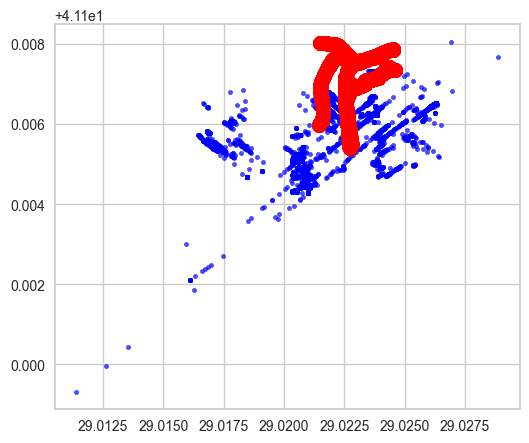

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4070 Ti SUPER, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

,Description,Value
0,Session id,42
1,Target,Longitude
2,Target type,Regression
3,Original data shape,"(165968, 60)"
4,Transformed data shape,"(165968, 6)"
5,Transformed train set shape,"(131123, 6)"
6,Transformed test set shape,"(34845, 6)"
7,Ignore features,10
8,Ordinal features,3
9,Numeric features,44


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4070 Ti SUPER, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000
1,0.0026,0.0000,0.0032,-1.9668,0.0001,0.0001
2,0.0030,0.0000,0.0030,-50.6006,0.0001,0.0001
Mean,0.0019,0.0000,0.0021,-17.5225,0.0001,0.0001
Std,0.0013,0.0000,0.0015,23.4036,0.0000,0.0000


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

...

,Description,Value
0,Session id,42
1,Target,Latitude
2,Target type,Regression
3,Original data shape,"(165968, 60)"
4,Transformed data shape,"(165968, 6)"
5,Transformed train set shape,"(131123, 6)"
6,Transformed test set shape,"(34845, 6)"
7,Ignore features,10
8,Ordinal features,3
9,Numeric features,44


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4070 Ti SUPER, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000
1,0.0013,0.0000,0.0014,-12.2802,0.0000,0.0000
2,0.0015,0.0000,0.0016,-4.3311,0.0000,0.0000
Mean,0.0009,0.0000,0.0010,-5.5371,0.0000,0.0000
Std,0.0007,0.0000,0.0007,5.0854,0.0000,0.0000


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,0.0016,0.0000,0.0020,-2.7703,0.0000,0.0000


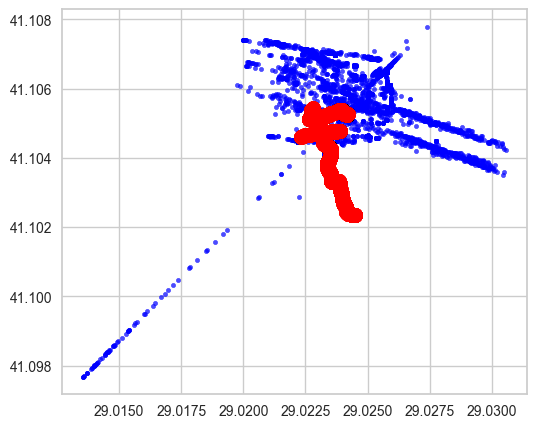

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4070 Ti SUPER, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

,Description,Value
0,Session id,42
1,Target,Longitude
2,Target type,Regression
3,Original data shape,"(181178, 60)"
4,Transformed data shape,"(181178, 6)"
5,Transformed train set shape,"(172390, 6)"
6,Transformed test set shape,"(8788, 6)"
7,Ignore features,10
8,Ordinal features,3
9,Numeric features,44


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4070 Ti SUPER, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000
1,0.0019,0.0000,0.0021,-5.9388,0.0001,0.0001
2,0.0018,0.0000,0.0020,-3.1493,0.0001,0.0001
Mean,0.0012,0.0000,0.0014,-3.0294,0.0000,0.0000
Std,0.0009,0.0000,0.0010,2.4260,0.0000,0.0000


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

...

,Description,Value
0,Session id,42
1,Target,Latitude
2,Target type,Regression
3,Original data shape,"(181178, 60)"
4,Transformed data shape,"(181178, 6)"
5,Transformed train set shape,"(172390, 6)"
6,Transformed test set shape,"(8788, 6)"
7,Ignore features,10
8,Ordinal features,3
9,Numeric features,44


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4070 Ti SUPER, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000
1,0.0007,0.0000,0.0009,-0.3698,0.0000,0.0000
2,0.0015,0.0000,0.0018,-0.0508,0.0000,0.0000
Mean,0.0007,0.0000,0.0009,-0.1402,0.0000,0.0000
Std,0.0006,0.0000,0.0007,0.1637,0.0000,0.0000


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,0.0013,0.0000,0.0015,-0.2457,0.0000,0.0000


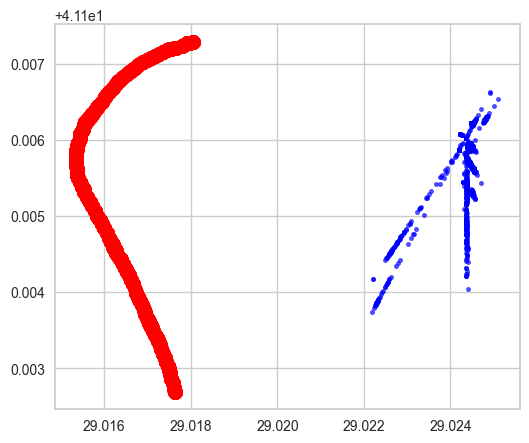

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4070 Ti SUPER, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

,Description,Value
0,Session id,42
1,Target,Longitude
2,Target type,Regression
3,Original data shape,"(180991, 60)"
4,Transformed data shape,"(180991, 6)"
5,Transformed train set shape,"(145075, 6)"
6,Transformed test set shape,"(35916, 6)"
7,Ignore features,10
8,Ordinal features,3
9,Numeric features,44


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4070 Ti SUPER, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0035,0.0000,0.0043,-0.0428,0.0001,0.0001
1,0.0023,0.0000,0.0026,-1.2748,0.0001,0.0001
2,0.0021,0.0000,0.0022,-12.3246,0.0001,0.0001
Mean,0.0026,0.0000,0.0030,-4.5474,0.0001,0.0001
Std,0.0006,0.0000,0.0009,5.5222,0.0000,0.0000


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

...

,Description,Value
0,Session id,42
1,Target,Latitude
2,Target type,Regression
3,Original data shape,"(180991, 60)"
4,Transformed data shape,"(180991, 6)"
5,Transformed train set shape,"(145075, 6)"
6,Transformed test set shape,"(35916, 6)"
7,Ignore features,10
8,Ordinal features,3
9,Numeric features,44


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4070 Ti SUPER, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.0056,0.0000,0.0059,-10.2979,0.0001,0.0001
1,0.0023,0.0000,0.0031,-0.2721,0.0001,0.0001
2,0.0017,0.0000,0.0022,-0.6627,0.0001,0.0000
Mean,0.0032,0.0000,0.0037,-3.7442,0.0001,0.0001
Std,0.0017,0.0000,0.0016,4.6369,0.0000,0.0000


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,0.0005,0.0000,0.0005,-4.5983,0.0000,0.0000


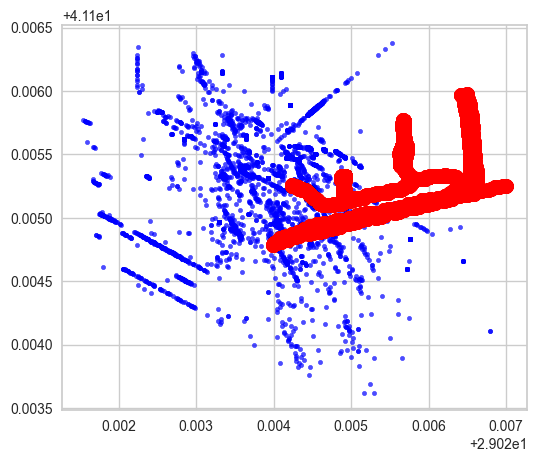

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4070 Ti SUPER, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

,Description,Value
0,Session id,42
1,Target,Longitude
2,Target type,Regression
3,Original data shape,"(154900, 60)"
4,Transformed data shape,"(154900, 6)"
5,Transformed train set shape,"(123860, 6)"
6,Transformed test set shape,"(31040, 6)"
7,Ignore features,10
8,Ordinal features,3
9,Numeric features,44


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4070 Ti SUPER, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000
1,0.0024,0.0000,0.0025,-6.8453,0.0001,0.0001
2,0.0020,0.0000,0.0021,-13.3605,0.0001,0.0001
Mean,0.0014,0.0000,0.0015,-6.7353,0.0001,0.0000
Std,0.0010,0.0000,0.0011,5.4550,0.0000,0.0000


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

...

,Description,Value
0,Session id,42
1,Target,Latitude
2,Target type,Regression
3,Original data shape,"(154900, 60)"
4,Transformed data shape,"(154900, 6)"
5,Transformed train set shape,"(123860, 6)"
6,Transformed test set shape,"(31040, 6)"
7,Ignore features,10
8,Ordinal features,3
9,Numeric features,44


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4070 Ti SUPER, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000
1,0.0020,0.0000,0.0020,-16.6366,0.0000,0.0000
2,0.0019,0.0000,0.0024,-1.2579,0.0001,0.0000
Mean,0.0013,0.0000,0.0015,-5.9648,0.0000,0.0000
Std,0.0009,0.0000,0.0011,7.5635,0.0000,0.0000


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,0.0007,0.0000,0.0009,-2.2219,0.0000,0.0000


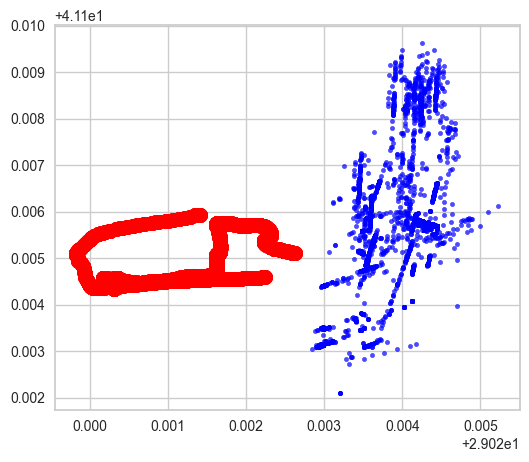

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4070 Ti SUPER, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

,Description,Value
0,Session id,42
1,Target,Longitude
2,Target type,Regression
3,Original data shape,"(112510, 60)"
4,Transformed data shape,"(112510, 6)"
5,Transformed train set shape,"(100083, 6)"
6,Transformed test set shape,"(12427, 6)"
7,Ignore features,10
8,Ordinal features,3
9,Numeric features,44


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4070 Ti SUPER, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,16:03:14
Status,. . . . . . . . . . . . . . . . . .,Finalizing Model
Estimator,. . . . . . . . . . . . . . . . . .,Linear Regression


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
predictions = pd.DataFrame()
haversine_distances = pd.DataFrame()

for i in aggc_train_test:
    train, test = df_fixed[[True if e in aggc_train_test[i] else False for e in df_fixed["cluster"]]], df_fixed[df_fixed["cluster"]==i]
    train, test = train.drop(columns=["cluster"]), test.drop(columns=["cluster"])

    temp_preds = pd.DataFrame()
    for target in ["Longitude","Latitude"]:
        ignore_feats = [
            'Time',
            "NAS_5GS_MM_MessageType",
            "NR_RRC_MsgType",
            "NR_UE_RRCReEst_EndResult",
            "NAS_5GS_SM_MessageType",
            "NR_UE_RACH_Procedure_Count",
            "NR_UE_Power_Tx_PRACH_0",
            "NR_UE_Nbr_RSRP_4",
            "NR_UE_Nbr_RSRQ_4"
        ]
        
        ordinal_feats = {
            "NR_UE_Modulation_Avg_DL_0": ["QPSK", "16QAM", "64QAM", "256QAM"],
            "NR_UE_RI_DL_0": ["Rank1", "Rank2", "Rank3", "Rank4"],
            "NR_UE_CCE_AggregationLev_0": ["LEVEL_1", "LEVEL_2", "LEVEL_4", "LEVEL_8", "LEVEL_16"],
            }
                
        if target == 'Longitude':
            ignore_feats.append('Latitude')
        else:
            ignore_feats.append('Longitude')

        clf_setup = setup( # noqa: F405
            data=train,
            test_data=test,
            target=target,
            ignore_features=ignore_feats,
            ordinal_features=ordinal_feats,
            imputation_type="iterative",
            iterative_imputation_iters = 1,
            numeric_iterative_imputer = "lightgbm",
            categorical_iterative_imputer= "lightgbm",
            #polynomial_features=True,
            fold = 3,
            feature_selection=False,
            verbose=True,
            session_id=42,
            log_data = True,
            pca=True,
            pca_components=5,
            use_gpu=True
            )
        
        lr_model = create_model('lr') # noqa : F405
        evaluate_model(lr_model) # noqa : F405
        
        temp_preds[f"predicted_{target}"] = predict_model(lr_model)["prediction_label"] # noqa : F405
        temp_preds[f"real_{target}"] = test[target]
        
    distances = haversine_np(
        temp_preds["predicted_Latitude"], 
        temp_preds["predicted_Longitude"], 
        temp_preds["real_Latitude"], 
        temp_preds["real_Longitude"]
        )
        
    fig = plt.figure(figsize=(6,5))
    ax = fig.add_subplot(1, 1, 1)

    sc = ax.scatter(
        temp_preds["predicted_Longitude"],
        temp_preds["predicted_Latitude"],
        c="blue",
        s=10,
        alpha=0.7
    )

    ax.scatter(
        temp_preds["real_Longitude"],
        temp_preds["real_Latitude"],
        s=100,
        c="red",   
    )

    plt.show()
        
    distance_stats = pd.DataFrame({"Test_Cluster": [i], "Mean_Distance": [distances.mean()], "Max_Distance": [distances.max()]})
    haversine_distances = pd.concat([haversine_distances, distance_stats])


    pd.concat([predictions,temp_preds])


In [26]:
predictions

""
